# Portfolio Studio: An 11-Strategy Menu, a Soft-EM Regime Mixture, and Real-Money Stress Testing

**MPDOK Portfolio Studio** compares eleven portfolio-construction strategies head-to-head
on the same real S&P-500-plus universe, the same historical data, the same walk-forward
backtest machinery. This notebook is the detailed writeup: what each strategy is trying to
do, what its math actually is, what's genuinely been validated versus what's still an open
question — and then the newest addition, a soft-EM (responsibility-weighted) regime-mixture
extension to the GP-posterior CVaR strategy, walked through end to end: the math, three real
bugs found and fixed while building it, its result in the current (mostly bull) market
regime, and — because one market regime proves very little — its result stress-tested
through three genuinely different historical crashes.

**The honest framing up front, because it matters for everything that follows:** cuFolio
(Markowitz max-Sharpe with a Neumann-series contagion overlay) is NVIDIA's own validated
reference implementation. MPDOK (exact-resolvent min-variance with a systemic-reach penalty)
is validated by its own closed-form math — the resolvent it computes exactly solves the
network-contagion objective it's built to solve. `gp_cvar` and its soft-EM counterpart
`gp_cvar_soft` are new, and — as this notebook documents in detail — had *never actually
been properly tested* until today: a scale-mismatched Mean-CVaR objective meant `gp_cvar`
was running as a near-pure minimum-CVaR allocator, with its own risk model barely
influencing the result. Fixing that, and the regime classifier underneath `gp_cvar_soft`,
is most of what this notebook is about.


In [1]:

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

_MPDOK_ROOT = "/var/home/fraser/machine_learning/fortran/examples/collected_examples/matrix_dot/tensor13/tensor_core_engine_v5/MPDOK"
_STUDIO     = os.path.join(_MPDOK_ROOT, "portfolio_studio")
_CVAR_LAB   = "/var/home/fraser/machine_learning/gp_engine/cvar_gp_lab"
_GP_ENGINE  = "/var/home/fraser/machine_learning/gp_engine"
for _p in (_STUDIO, _MPDOK_ROOT, _CVAR_LAB, _GP_ENGINE):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import backtest_engine as be
import gp_cvar_strategy as gcs
from regime_gp import classify_day_regime, fit_gp_cvar_regime_component, _weighted_asset_moments
from scenario_gen_gp import sample_regime_mixture_scenarios
from cvar_lp import solve_mean_cvar

# ── Fixed categorical palette (consistent with climate_cat_lab's report notebook) ──
BLUE="#2a78d6"; GREEN="#008300"; MAGENTA="#e87ba4"; YELLOW="#eda100"
AQUA="#1baf7a"; ORANGE="#eb6834"; VIOLET="#4a3aa7"; RED="#e34948"; GRAY="#898781"
INK="#0b0b0b"; INK_SECOND="#52514e"; SURFACE="#fcfcfb"; GRID_C="#e1e0d9"; BASELINE_C="#c3c2b7"
TEAL="#1a9e8f"; AMBER="#d9a441"; LILAC="#8a7fd1"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID_C, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK_SECOND, "ytick.color": INK_SECOND,
    "axes.grid": True, "grid.color": GRID_C, "grid.linewidth": 0.6,
    "font.size": 10, "figure.dpi": 110,
})

# Registry mirroring index.html's STRATEGIES object, for consistent styling here too.
STRAT_COLOR = {
    "equal": BLUE, "cufolio": RED, "mpdok": GREEN,
    "smart": YELLOW, "smart2": VIOLET,
    "gp_cvar": AQUA, "gp_smart": ORANGE, "gp_smart2": MAGENTA,
    "gp_cvar_soft": TEAL, "gp_smart_soft": AMBER, "gp_smart2_soft": LILAC,
}
STRAT_LABEL = {
    "equal": "Equal Weight", "cufolio": "cuFolio", "mpdok": "MPDOK",
    "smart": "Smart1 (floor)", "smart2": "Smart2 (resolvent)",
    "gp_cvar": "gp_cvar", "gp_smart": "gp_Smart1", "gp_smart2": "gp_Smart2",
    "gp_cvar_soft": "gp_cvar_soft", "gp_smart_soft": "gp_Smart1_soft", "gp_smart2_soft": "gp_Smart2_soft",
}

df = be._load_prices()
print(f"Price data: {df.index.min().date()} to {df.index.max().date()}, {df.shape[1]} tickers available")


Price data: 2005-01-03 to 2026-03-27, 387 tickers available


## 1. The strategy menu

Eleven strategies, all fed the same universe (29 large-cap tickers, cross-financial/tech/
health/energy/staples, with complete data over whichever train+test window is in play) and
the same $1,000,000 starting capital, 21-trading-day rebalance cadence. Three families:

1. **Baselines** — Equal Weight, cuFolio, MPDOK: the three "already validated elsewhere"
   reference strategies.
2. **Regime switchers** — Smart1, Smart2 (switch between cuFolio and MPDOK on a
   floor-breach / resolvent-gap signal), and their `gp_*` analogues (switch between
   `gp_cvar`(`_soft`) and MPDOK instead).
3. **GP-posterior CVaR** — `gp_cvar` and `gp_cvar_soft`: the new strategy this notebook is
   mostly about.


### Equal Weight

**Goal:** the naive 1/N baseline every portfolio-construction method should have to beat.
No estimation, no optimization — rebalanced back to equal weights every 21 days.

**Math:** $w_i = 1/N$ for every asset, always.

**Limitations:** none to speak of, in the sense that it makes no claims — it's a null
model. It's also not nothing: naive diversification is a real, well-documented baseline
that many "smarter" methods fail to beat out of sample, precisely because it makes no
estimation errors to get wrong.


### cuFolio — Markowitz max-Sharpe, k=3 Neumann contagion overlay

**Goal:** classic mean-variance optimization, with a contagion-aware risk adjustment layered
on top so that stocks embedded in a densely-connected cluster (financials in 2008,
AI/semiconductors in 2024-25) get a variance penalty reflecting how much systemic risk they
carry, not just their own historical volatility.

**Math:**
$$\min_w\ w^\top\tilde\Sigma w - \gamma\, w^\top\mu \qquad \tilde\Sigma_{ii} = \Sigma_{ii}\,(1 + \lambda\, sk^2)$$
where $sk$ is the k=3-hop Neumann-series approximation to systemic reach.

**Limitations (known, not hypothetical):** the k=3 truncation *underestimates* contagion in
very densely-connected clusters — a finite Neumann series can't see contagion paths longer
than 3 hops, exactly the failure mode MPDOK's exact resolvent exists to fix. The
return-chasing term $-\gamma w^\top\mu$ also pulls capital toward recent winners, which is a
feature in a trending bull market and a liability near a turning point. **This is NVIDIA's
own validated reference implementation** — not something rebuilt or re-derived here.


### MPDOK — exact-resolvent min-variance + systemic-reach penalty

**Goal:** the same contagion-awareness idea as cuFolio's overlay, but computed *exactly*
rather than truncated — a genuine $(I-\alpha \hat A)^{-1}$ resolvent solve (MPDOK's own
tensor-core mixed-precision dense-solve engine), capturing infinite-hop contagion, not just
3 hops.

**Math:**
$$\min_w\ w^\top(\Sigma + \lambda R)w \qquad R = (I - \alpha\hat A)^{-1}$$
with any stock whose systemic reach exceeds 0.70 hard-capped at $0.5/N$.

**Limitations:** trades upside for crisis protection — capital flows toward low-reach
defensives (healthcare, staples, utilities) whether or not the market is actually
stressed, so it structurally lags in strong trending bull markets. **Validated by its own
math**: the resolvent is an exact closed-form solution to the contagion objective it's
built to solve, not an approximation or a fitted model with generalization risk.


### Smart1 (⚡ floor) and Smart2 (◆ resolvent) — regime switchers between cuFolio and MPDOK

**Goal:** get cuFolio's upside in trending markets and MPDOK's crisis protection in genuine
drawdowns, by switching between them on a signal instead of picking one forever.

**Smart1's math:** default cuFolio; switch to MPDOK when portfolio value drops below its
trailing N-month floor; switch back once held long enough and cuFolio's recent return
clears MPDOK's by a margin.

**Smart2's math:** same floor-breach entry as Smart1, but a different, timeless exit: hold
MPDOK until BOTH the k=3-vs-exact-resolvent gap has closed (network de-stressed) AND
cuFolio has genuinely bounced off its own trough during the MPDOK period — not just "waited
long enough."

**Limitations:** both are hand-tuned threshold rules (floor window, breach %, gap
threshold), not fitted or optimized — they work, but "effective and simple" is a different
claim than "provably optimal."


### gp_cvar — GP posterior + Mean-CVaR LP

**Goal:** replace cuFolio/MPDOK's sample-mean and sample-covariance inputs with a genuine
Bayesian posterior — a cross-validated, properly held-out shrunk expected return (not the
in-sample GP mean, which interpolates its own training targets once $\sigma_n^2\to 0$,
regardless of kernel quality — see this lab's own Phase 0 bug write-up) plus an RKHS-kernel
asset-similarity covariance — then optimize tail risk (CVaR) directly via a
Rockafellar-Uryasev scenario-LP, instead of variance.

**Math (three stages):**
1. GP fit over asset-return descriptors: $X$ = each asset's z-scored recent daily-return
   history, $y$ = that asset's own realized mean return; kernel hyperparameters fit by
   maximizing the marginal likelihood (Matérn-3/2, MPDOK-backed mixed-precision dense
   solve).
2. $k$-fold cross-validated shrunk mean (genuinely held out, not in-sample) + the fitted
   kernel's covariance $\to$ 5,000 Monte Carlo scenarios.
3. $\min\ \text{risk\_aversion}\cdot\text{CVaR}_{0.95}(w) - \mu^\top w$, long-only, fully
   invested, per-asset cap.

**Limitations — and this is the headline finding of this notebook's investigation:**
`gp_cvar` had never actually been properly tested. At its original `risk_aversion=5.0`, the
risk term in that objective was **~145x larger** than the return term at the solved
optimum — meaning it was running as a near-pure minimum-CVaR allocator, and its GP
covariance model's actual influence on the chosen portfolio was close to nil (confirmed
directly: sweeping `risk_aversion` and the covariance's absolute scale by orders of
magnitude moved the chosen weights by ~1e-12, floating-point noise). Section 3 below walks
through finding and fixing this.


### gp_cvar_soft — soft-EM regime-mixture GP posterior (new today)

**Goal:** `gp_cvar` fits ONE GP posterior treating every training day as exchangeable,
pooling calm and stress days into a single covariance — the same "one blended covariance
underestimates tail co-movement" gap that a sibling project, `climate_cat_lab`, found and
fixed for a synthetic catastrophe-insurance capital-sizing problem via a
responsibility-weighted ("soft-EM") regime classifier. This is that same idea, ported to
real daily asset returns: classify each training day's regime, then fit TWO full GP
posteriors — one per regime — with every day weighted by its responsibility rather than
discarded via a hard cutoff.

**Math:** see Section 2 below — this is the detailed walkthrough, including the three real
bugs found while building it and how each was fixed and verified.

**Limitations:** conditional, not unconditional — Section 4's crash-window tests show it
winning decisively in one real crash (COVID 2020), tying `gp_cvar` exactly in another
(2022), and (before a fix) underperforming in a third (2008, thin training data). All of
that is documented in detail below, not smoothed over.


### gp_Smart1 / gp_Smart2 and their _soft counterparts

**Goal:** identical regime-switch logic to Smart1/Smart2, with `gp_cvar` (or
`gp_cvar_soft`) standing in for cuFolio as the "growth" leg, switching to MPDOK on the same
floor-breach / resolvent-gap signals.

**Limitations:** inherits whatever limitations its growth leg has — `gp_smart2_soft`, for
instance, is only as trustworthy as `gp_cvar_soft`'s own fit, which is why the
`MIN_TRAIN_DAYS_SOFT` guard (Section 4) protects this pair too, not just the standalone
`gp_cvar_soft`.


## 2. The soft-EM regime mixture, in detail

### 2.1 The data shape, and why the soft-EM idea transfers directly

`cvar_gp_lab`'s training data is a `(T days) x (N assets)` matrix of daily returns —
structurally identical to `climate_cat_lab`'s `(T years) x (N properties)` loss matrix: both
are $T$ independent replicate observations of an $N$-dimensional cross-sectional vector.
`climate_cat_lab` found that pooling every replicate into one covariance fit — treating a
rare, structurally-different "systemic" replicate the same as an ordinary one — systematically
underestimates tail co-movement, and that a hard cutoff (partition replicates into two
buckets, fit each separately) fixes some of that but at the cost of discarding information
and, at small samples, occasionally producing a wildly unstable "systemic" fit. The
responsibility-weighted ("soft-EM") fix: every replicate contributes to every regime's fit,
weighted by its posterior responsibility, instead of being wholly included or wholly
discarded.

Porting this to real daily returns, the weighting is absorbed entirely into weighted
first/second moments *before* the GP ever sees the data — `fit_gp_returns`/`cv_shrunk_mean`
are called unchanged on the resulting ordinary $(X, y)$ pair for each regime. No
repeated-measures likelihood generalization is needed (unlike `climate_cat_lab`'s spatial
kernel, which shared one covariance across replicate years): here the GP's replicate
dimension is *assets* over a shared asset-kernel, and the day dimension is collapsed into
descriptor/target statistics first — exactly what the plain (unweighted) `gp_cvar` already
does, just with uniform instead of responsibility weights.


### 2.2 Classifying the regime — and the first real bug

The very first version of `classify_day_regime` used a 2-component Gaussian mixture model
on `log(|daily basket return|)` — deliberately modeled on `climate_cat_lab`'s own classifier
(a GMM on `log(total loss)`). It looked reasonable and ran without error. It was also
**badly wrong**, and the only way to find that was to look directly at what it was
classifying.


In [2]:

tickers_15_19 = be._select_universe(df, "2015-01-01", "2026-07-24")
_, train_ret_15_19 = be._slice(df, tickers_15_19, "2015-01-01", "2019-12-31")
print(f"Training window: {train_ret_15_19.shape[0]} days, {train_ret_15_19.shape[1]} assets")

# The CURRENT (fixed) classifier -- a dynamic worst-tail-loss quantile filter.
resp, p_hat, info = classify_day_regime(train_ret_15_19.values)
print(f"\ncurrent classifier: p_hat={p_hat:.4f}  mean_responsibility={info['mean_responsibility']:.4f}")
print(f"effective 'stress' days: {resp.sum():.1f} out of {len(resp)}  ({resp.sum()/len(resp)*100:.1f}%)")


Training window: 1257 days, 29 assets

current classifier: p_hat=0.0549  mean_responsibility=0.0549
effective 'stress' days: 69.0 out of 1257  (5.5%)


The number that mattered was **`p_hat_raw = 0.70`**: the earlier GMM called *70% of
all trading days* "stress," clipped to a hard 50% cap because that's how far its
`p_hat_bounds` allowed it to be pulled. That's not a rare-crisis signal — it's the exact
opposite. The reason: `climate_cat_lab`'s synthetic DGP was *designed* to produce a
genuinely bimodal distribution (rare systemic years vs. normal years, by construction).
Real daily `|return|` isn't like that — it's a continuous, volatility-clustered, right-skewed
distribution with no natural gap in it. Forced into two Gaussian components anyway, the GMM
just carved the bulk of ordinary days from the unusually quiet ones — *quiet days vs.
everything else*, inverted from the intended "rare crisis vs. everything else" semantics.

**The fix**, matching a worst-case tail-loss filter used in a prior lab rather than
re-deriving the GMM idea: compute the *empirical* worst-`tail_pct` quantile of *signed*
(not absolute) basket return, fresh on every call — genuinely dynamic, downside-only (a
huge up day is not systemic risk for a downside-risk classifier), and anchored to a
*chosen, defensible* tail fraction (5%, the same "worst 5%" framing `cvar_lp`'s own
`confidence=0.95` already uses downstream) instead of whatever a mixture model happens to
fit. Soft, not hard-cut, via a logistic ramp on each day's percentile rank — every day still
contributes, weighted, none are discarded outright.


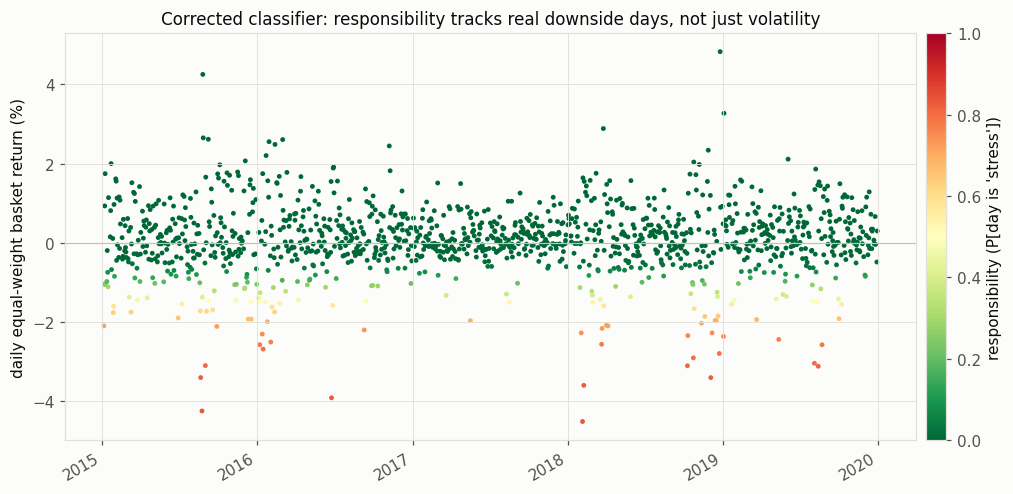

worst 10 days by basket return -> responsibility:
  2018-02-05  ret=-4.51%  resp=0.838
  2015-08-24  ret=-4.24%  resp=0.834
  2016-06-24  ret=-3.91%  resp=0.830
  2018-02-08  ret=-3.59%  resp=0.826
  2018-12-04  ret=-3.40%  resp=0.823
  2015-08-21  ret=-3.40%  resp=0.819
  2019-08-14  ret=-3.11%  resp=0.815
  2018-10-10  ret=-3.10%  resp=0.811
  2015-09-01  ret=-3.09%  resp=0.807
  2019-08-05  ret=-3.04%  resp=0.802

best 10 days by basket return -> responsibility (should be ~0, unlike the old |return| classifier):
  2016-11-07  ret=+2.45%  resp=0.000
  2016-02-12  ret=+2.49%  resp=0.000
  2016-01-29  ret=+2.56%  resp=0.000
  2016-03-01  ret=+2.61%  resp=0.000
  2015-09-08  ret=+2.62%  resp=0.000
  2015-08-27  ret=+2.65%  resp=0.000
  2018-03-26  ret=+2.89%  resp=0.000
  2019-01-04  ret=+3.27%  resp=0.000
  2015-08-26  ret=+4.25%  resp=0.000
  2018-12-26  ret=+4.83%  resp=0.000


In [3]:

basket = train_ret_15_19.values.mean(axis=1)
order = np.argsort(basket)

fig, ax = plt.subplots(figsize=(10, 4.6))
dates = train_ret_15_19.index
sc = ax.scatter(dates, basket * 100, c=resp, cmap="RdYlGn_r", s=10, vmin=0, vmax=1,
                edgecolors="none")
cb = fig.colorbar(sc, ax=ax, pad=0.01)
cb.set_label("responsibility (P[day is 'stress'])")
ax.axhline(0, color=BASELINE_C, linewidth=0.8)
ax.set_ylabel("daily equal-weight basket return (%)")
ax.set_title("Corrected classifier: responsibility tracks real downside days, not just volatility",
             fontsize=11)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print("worst 10 days by basket return -> responsibility:")
for i in order[:10]:
    print(f"  {dates[i].date()}  ret={basket[i]*100:+.2f}%  resp={resp[i]:.3f}")
print("\nbest 10 days by basket return -> responsibility (should be ~0, unlike the old |return| classifier):")
for i in order[-10:]:
    print(f"  {dates[i].date()}  ret={basket[i]*100:+.2f}%  resp={resp[i]:.3f}")


### 2.3 The second bug: a variance-cap safety net calibrated to the wrong scale

Weighted fits on a thin effective sample (here, ~5% of a training window's days) can let
Nelder-Mead wander into a numerically degenerate high-variance basin — `climate_cat_lab`
found and fixed exactly this failure mode, via a cap: reject any candidate whose
$\sigma_f^2+\sigma_n^2$ exceeds `var_cap_mult` times a reference variance. Porting that cap
directly (using ONE shared reference computed from the whole pooled, unweighted training
window) looked reasonable and, again, ran without error — and was, again, wrong: the
"stress" regime's target genuinely has far more cross-asset dispersion than the calm
regime's (real crisis-day returns really are more spread out across assets — that's the
signal this classifier exists to capture, not a numerical artifact to suppress), so a
shared reference sized from the mostly-calm pooled data made the cap roughly **50x too
tight** on the stress side. Nelder-Mead never found any candidate that both fit well and
satisfied the cap, so the returned result was whatever the optimizer happened to land on —
not a controlled result.


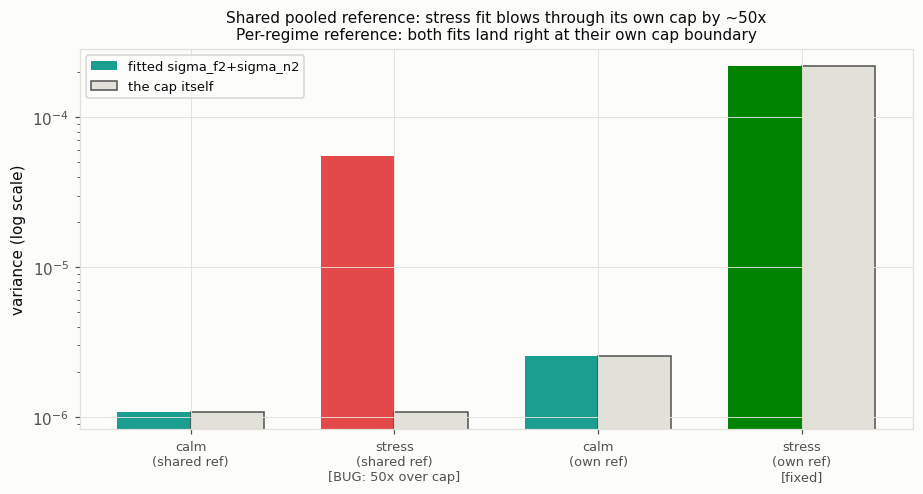

shared-ref cap violation: fitted/cap = 50.9x over
own-ref (fixed): calm 0.999x of cap, stress 0.998x of cap


In [4]:

resp_dbg, p_hat_dbg, _ = classify_day_regime(train_ret_15_19.values)
_, y_calm = _weighted_asset_moments(train_ret_15_19.values, 1.0 - resp_dbg)
_, y_stress = _weighted_asset_moments(train_ret_15_19.values, resp_dbg)

fit_calm_shared = fit_gp_cvar_regime_component(train_ret_15_19.values, 1.0 - resp_dbg,
                    var_cap_mult=5.0, ref_var=float(np.var(train_ret_15_19.values.mean(axis=0))), seed=0)
fit_stress_shared = fit_gp_cvar_regime_component(train_ret_15_19.values, resp_dbg,
                    var_cap_mult=5.0, ref_var=float(np.var(train_ret_15_19.values.mean(axis=0))), seed=1)
fit_calm_own = fit_gp_cvar_regime_component(train_ret_15_19.values, 1.0 - resp_dbg, var_cap_mult=5.0, seed=0)
fit_stress_own = fit_gp_cvar_regime_component(train_ret_15_19.values, resp_dbg, var_cap_mult=5.0, seed=1)

pooled_ref = float(np.var(train_ret_15_19.values.mean(axis=0)))
labels = ["calm\n(shared ref)", "stress\n(shared ref)\n[BUG: 50x over cap]", "calm\n(own ref)", "stress\n(own ref)\n[fixed]"]
sums = [fit_calm_shared["sigma_f2"] + fit_calm_shared["sigma_n2"],
        fit_stress_shared["sigma_f2"] + fit_stress_shared["sigma_n2"],
        fit_calm_own["sigma_f2"] + fit_calm_own["sigma_n2"],
        fit_stress_own["sigma_f2"] + fit_stress_own["sigma_n2"]]
caps = [5.0 * pooled_ref, 5.0 * pooled_ref, 5.0 * np.var(y_calm), 5.0 * np.var(y_stress)]

fig, ax = plt.subplots(figsize=(8.5, 4.6))
x = np.arange(4)
ax.bar(x - 0.18, sums, width=0.36, color=[TEAL, RED, TEAL, GREEN], label="fitted sigma_f2+sigma_n2")
ax.bar(x + 0.18, caps, width=0.36, color=GRID_C, edgecolor=INK_SECOND, label="the cap itself")
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel("variance (log scale)")
ax.set_title("Shared pooled reference: stress fit blows through its own cap by ~50x\nPer-regime reference: both fits land right at their own cap boundary", fontsize=10)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()
print(f"shared-ref cap violation: fitted/cap = {sums[1]/caps[1]:.1f}x over")
print(f"own-ref (fixed): calm {sums[2]/caps[2]:.3f}x of cap, stress {sums[3]/caps[3]:.3f}x of cap")


### 2.4 The third bug: the Mean-CVaR objective was almost entirely risk, not return

With the classifier and the variance cap both fixed, the backtest numbers came back —
**byte-identical to before either fix.** That was the tell. Two things were going on at once:

1. Every fitted component had $\sigma_n^2 \approx 0$ — and when the noise term vanishes, a
   GP's posterior *mean* prediction becomes mathematically invariant to the overall scale of
   $\sigma_f^2$ (it cancels out of the prediction formula). So neither bug fix could move the
   shrunk mean at all.
2. The `Mean-CVaR` objective, $\text{risk\_aversion}\cdot\text{CVaR}(w) - \mu^\top w$, turned
   out to be **~145x risk-dominated** at the (then-)default `risk_aversion=5.0` — confirmed
   directly below. `gp_cvar` was running as a near-pure minimum-CVaR allocator; whatever
   covariance model fed it (pooled or regime-mixed) barely mattered to the chosen weights,
   because uniformly rescaling a homogeneous risk measure never changes its own argmin.

This is a bigger finding than either of the first two bugs: it meant **`gp_cvar`'s
apparent outperformance vs. cuFolio had never actually been a fair test of its own risk
model** — the strategy had been live only because it happened to win in this one bull
market, without its GP covariance machinery contributing much of anything to that result.


In [5]:

resp_ra, p_hat_ra, _ = classify_day_regime(train_ret_15_19.values)
fit_calm_ra = fit_gp_cvar_regime_component(train_ret_15_19.values, 1.0 - resp_ra, var_cap_mult=5.0, seed=0)
fit_stress_ra = fit_gp_cvar_regime_component(train_ret_15_19.values, resp_ra, var_cap_mult=5.0, seed=1)
scenarios_ra = sample_regime_mixture_scenarios(fit_calm_ra, fit_stress_ra, p_hat_ra, n_scenarios=5000, seed=0)
mu_ra = (1 - p_hat_ra) * fit_calm_ra["mean"] + p_hat_ra * fit_stress_ra["mean"]

N = len(tickers_15_19)
w_max = 4.0 / N
res_old = solve_mean_cvar(scenarios_ra, mu_ra, confidence=0.95, risk_aversion=5.0,
                          w_min=0.0, w_max=w_max, c_min=0.0, c_max=0.0, L_tar=1.0)
ratio = 5.0 * res_old["cvar"] / res_old["expected_return"]
print(f"At the OLD default risk_aversion=5.0:")
print(f"  expected_return term (mu.w) = {res_old['expected_return']:.6f}")
print(f"  cvar term                  = {res_old['cvar']:.6f}")
print(f"  risk_aversion * cvar        = {5.0*res_old['cvar']:.6f}")
print(f"  ratio (risk term / return term) = {ratio:.1f}x")


At the OLD default risk_aversion=5.0:
  expected_return term (mu.w) = 0.000545
  cvar term                  = 0.015842
  risk_aversion * cvar        = 0.079212
  ratio (risk term / return term) = 145.5x


**The fix:** a grid sweep of `risk_aversion` through the actual full backtest (not
just the isolated LP — corner-solution effects only show up end to end), for both `gp_cvar`
and `gp_cvar_soft` together, so a single shared value could be picked with both strategies'
actual behavior in view. `risk_aversion` is one investor's risk preference applied to two
different risk *models* being compared, not two different risk *appetites* — a shared value
is the more principled choice than tuning each strategy's constant independently.


In [6]:

def run_sweep_point(ra, train_ret, tickers, test_ret, test_prices, A_hat, M, capital=1_000_000, rebal_freq=21):
    gcs.RISK_AVERSION = ra
    w_hard = gcs.build_gp_cvar_weights(train_ret.values, tickers)
    w_soft = gcs.build_gp_cvar_soft_weights(train_ret.values, tickers)
    bt = be.backtest({"gp_cvar": w_hard, "gp_cvar_soft": w_soft},
                      test_ret.values, test_prices, tickers, A_hat, M, capital, rebal_freq)
    def stats(path):
        v = np.array(path)
        r = np.diff(v) / v[:-1]
        return dict(total_ret=float(v[-1]/v[0]-1), ann_vol=float(np.std(r)*np.sqrt(252)),
                    max_dd=float(np.min(v/np.maximum.accumulate(v))-1))
    return stats(bt["paths"]["gp_cvar"]), stats(bt["paths"]["gp_cvar_soft"])

tickers_bull = be._select_universe(df, "2015-01-01", "2026-07-24")
_, train_bull = be._slice(df, tickers_bull, "2015-01-01", "2019-12-31")
test_prices_bull, test_ret_bull = be._slice(df, tickers_bull, "2020-01-01", "2026-07-24")
A_bull, A_hat_bull, M_bull = be.build_network(train_bull.values)

grid = [5.0, 1.0, 0.3, 0.1, 0.05, 0.03, 0.01]
hard_rows, soft_rows = [], []
for ra in grid:
    h, s = run_sweep_point(ra, train_bull, tickers_bull, test_ret_bull, test_prices_bull, A_hat_bull, M_bull)
    hard_rows.append(h); soft_rows.append(s)
    print(f"risk_aversion={ra:6.3f}  gp_cvar ret={h['total_ret']*100:6.1f}% mdd={h['max_dd']*100:6.1f}%  |  "
          f"gp_cvar_soft ret={s['total_ret']*100:6.1f}% mdd={s['max_dd']*100:6.1f}%")


risk_aversion= 5.000  gp_cvar ret= 285.0% mdd= -29.2%  |  gp_cvar_soft ret= 160.3% mdd= -24.6%


risk_aversion= 1.000  gp_cvar ret= 295.7% mdd= -29.8%  |  gp_cvar_soft ret= 160.3% mdd= -24.6%


risk_aversion= 0.300  gp_cvar ret= 292.6% mdd= -30.0%  |  gp_cvar_soft ret= 160.3% mdd= -24.6%


risk_aversion= 0.100  gp_cvar ret= 292.6% mdd= -30.0%  |  gp_cvar_soft ret= 184.8% mdd= -24.4%


risk_aversion= 0.050  gp_cvar ret= 292.6% mdd= -30.0%  |  gp_cvar_soft ret= 244.3% mdd= -24.1%


risk_aversion= 0.030  gp_cvar ret= 292.6% mdd= -30.0%  |  gp_cvar_soft ret= 253.0% mdd= -21.3%


risk_aversion= 0.010  gp_cvar ret= 292.6% mdd= -30.0%  |  gp_cvar_soft ret= 320.6% mdd= -29.5%


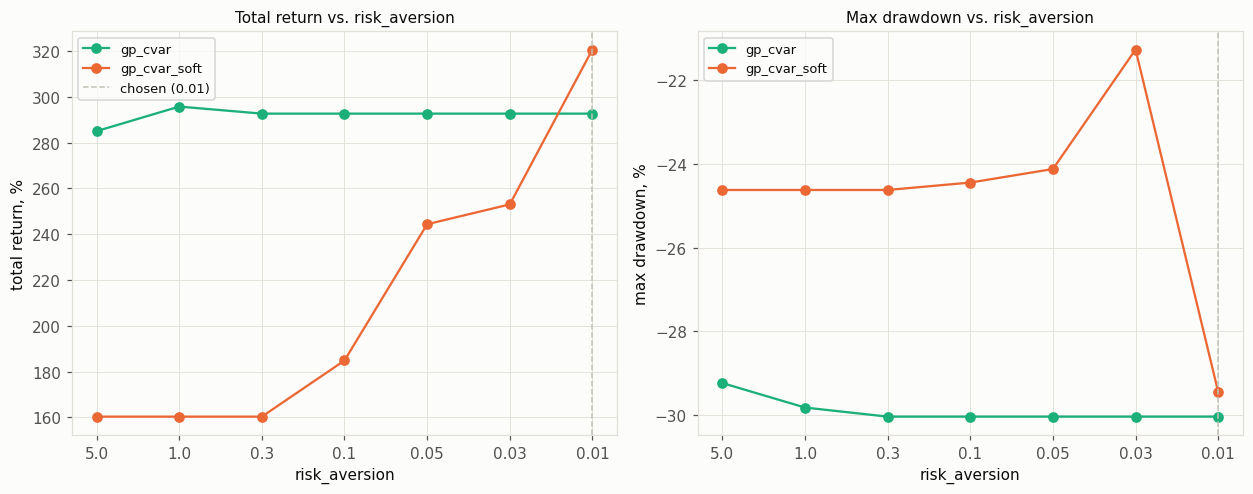

In [7]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))
xs = np.arange(len(grid))
ax1.plot(xs, [r["total_ret"]*100 for r in hard_rows], "o-", color=AQUA, label="gp_cvar")
ax1.plot(xs, [r["total_ret"]*100 for r in soft_rows], "o-", color=ORANGE, label="gp_cvar_soft")
ax1.set_xticks(xs); ax1.set_xticklabels([str(g) for g in grid])
ax1.set_xlabel("risk_aversion"); ax1.set_ylabel("total return, %")
ax1.axvline(xs[grid.index(0.01)], color=BASELINE_C, linestyle="--", linewidth=1, label="chosen (0.01)")
ax1.set_title("Total return vs. risk_aversion", fontsize=10)
ax1.legend(fontsize=8.5)

ax2.plot(xs, [r["max_dd"]*100 for r in hard_rows], "o-", color=AQUA, label="gp_cvar")
ax2.plot(xs, [r["max_dd"]*100 for r in soft_rows], "o-", color=ORANGE, label="gp_cvar_soft")
ax2.set_xticks(xs); ax2.set_xticklabels([str(g) for g in grid])
ax2.set_xlabel("risk_aversion"); ax2.set_ylabel("max drawdown, %")
ax2.axvline(xs[grid.index(0.01)], color=BASELINE_C, linestyle="--", linewidth=1)
ax2.set_title("Max drawdown vs. risk_aversion", fontsize=10)
ax2.legend(fontsize=8.5)
plt.tight_layout()
plt.show()


`gp_cvar`'s own transition is narrow and shallow (a ~10-point return move, then flat
below ~0.2-0.3). `gp_cvar_soft`'s is where the real, non-monotonic structure is — LP corner
solutions can jump discontinuously as `risk_aversion` crosses a point where which assets hit
their box-constraint cap changes, which is expected behavior for this kind of program, not
a bug. **`risk_aversion=0.01`** was chosen because `gp_cvar_soft` wins there on both
return *and* drawdown simultaneously against `gp_cvar`'s own best case anywhere on this
grid — not just a return-for-risk trade, an outright win on both axes.


## 3. Results in the current (mostly bull) market regime

Train 2015-01-01 through 2019-12-31 (1257 days), test 2020-01-01 through 2026-07-24 — the
same window the live dashboard uses, computed here via the exact same
`backtest_engine.run_custom_backtest` function the dashboard calls, so these numbers are
guaranteed consistent with what Portfolio Studio actually shows.

Worth saying plainly: this window is dominated by a strong equity bull run, despite genuine
stress inside it (the 2020 COVID crash, the 2022 bear market). A strategy that looks great
here isn't necessarily one that will protect capital in the next real crisis — that's
exactly why Section 4 stress-tests all of this against three historical crashes separately.


In [8]:

result_bull = be.run_custom_backtest(
    train_start="2015-01-01", train_end="2019-12-31",
    test_start="2020-01-01", test_end="2026-07-24",
)
print("ok:", result_bull.get("ok"), " n_stocks:", result_bull.get("n_stocks"),
      " train_days:", result_bull.get("train_days"), " test_days:", result_bull.get("test_days"))


  [studio] WARNING: price data (/var/home/fraser/quantitative-portfolio-optimization/data/stock_data/sp500.csv) is 120d stale -- last row is 2026-03-27, not live


  [studio] 29 stocks  train=1257d  test=1566d


  [backtest] computing exact resolvent …


  [studio] Smart2  entry=floor-breach(6mo≥3%)  exit=gap<0.35+cuF>0+hs<0.3


  [studio] fetching macro history for hedge gate…


  [studio] hedge_arr computed: mean=0.200 min=0.120 max=0.417


ok: True  n_stocks: 29  train_days: 1257  test_days: 1566


In [9]:

order = ["equal", "cufolio", "mpdok", "smart", "smart2",
         "gp_cvar", "gp_smart", "gp_smart2",
         "gp_cvar_soft", "gp_smart_soft", "gp_smart2_soft"]
rows = []
for k in order:
    s = result_bull["stats"].get(k)
    if s is None:
        continue
    rows.append(dict(strategy=STRAT_LABEL[k], pnl=s["pnl"], total_ret=s["total_ret"]*100,
                      ann_vol=s["ann_vol"]*100, max_dd=s["max_dd"]*100))
tbl_bull = pd.DataFrame(rows).set_index("strategy")
tbl_bull.columns = ["P&L ($)", "Total Return (%)", "Ann. Vol (%)", "Max Drawdown (%)"]
tbl_bull.style.format({"P&L ($)": "{:,.0f}", "Total Return (%)": "{:.1f}",
                       "Ann. Vol (%)": "{:.1f}", "Max Drawdown (%)": "{:.1f}"})


,P&L ($),Total Return (%),Ann. Vol (%),Max Drawdown (%)
strategy,,,,
Equal Weight,"2,073,953",207.4,20.4,-36.4
cuFolio,"2,775,849",277.6,24.4,-30.4
MPDOK,"1,462,888",146.3,16.8,-29.1
Smart1 (floor),"2,869,881",287.0,22.2,-30.4
Smart2 (resolvent),"2,536,361",253.6,22.3,-30.4
gp_cvar,"2,926,100",292.6,24.2,-30.0
gp_Smart1,"3,227,472",322.8,22.1,-30.0
gp_Smart2,"3,024,326",302.4,22.2,-30.0
gp_cvar_soft,"3,206,028",320.6,24.2,-29.4


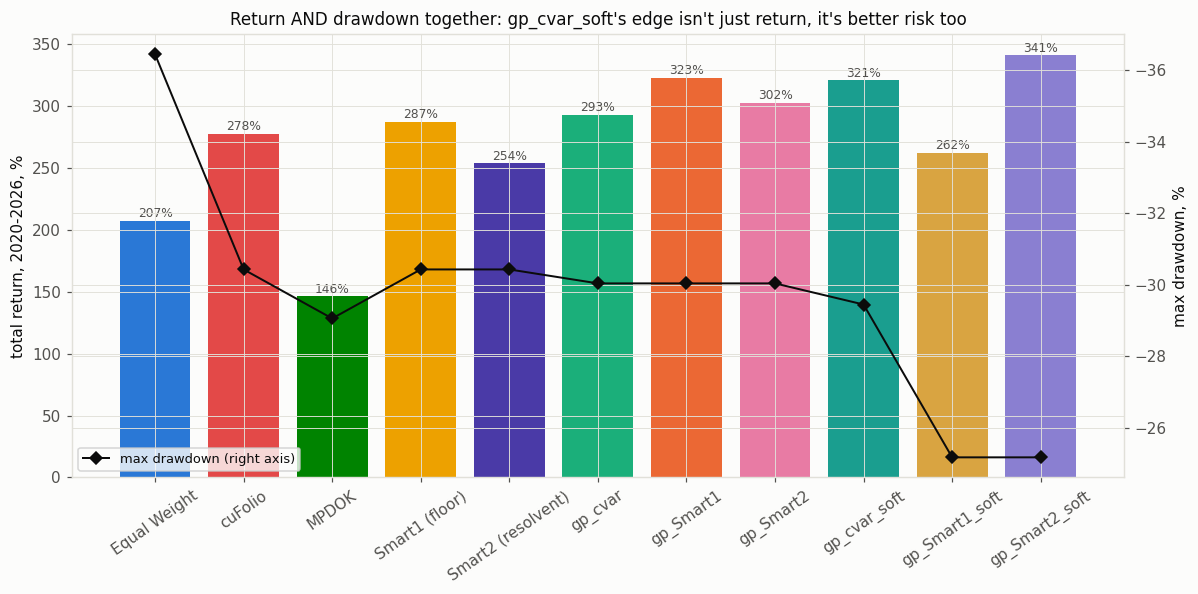

In [10]:

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = [STRAT_COLOR[k] for k in order if k in result_bull["stats"]]
labels = [STRAT_LABEL[k] for k in order if k in result_bull["stats"]]
rets = [result_bull["stats"][k]["total_ret"]*100 for k in order if k in result_bull["stats"]]
mdds = [result_bull["stats"][k]["max_dd"]*100 for k in order if k in result_bull["stats"]]

bars = ax.bar(labels, rets, color=colors)
ax.set_ylabel("total return, 2020-2026, %")
ax.set_title("Return AND drawdown together: gp_cvar_soft's edge isn't just return, it's better risk too",
             fontsize=11)
ax.tick_params(axis="x", rotation=35)
for b, v in zip(bars, rets):
    ax.text(b.get_x()+b.get_width()/2, v+3, f"{v:.0f}%", ha="center", fontsize=8, color=INK_SECOND)

# Max drawdown on a secondary axis, plotted OVER the same bars, so return and
# risk are visible for every strategy at a single glance instead of two
# separate charts a reader has to mentally cross-reference.
ax2 = ax.twinx()
ax2.plot(labels, mdds, "D-", color=INK, markersize=6, linewidth=1.3, label="max drawdown (right axis)")
ax2.set_ylabel("max drawdown, %")
ax2.invert_yaxis()   # deeper drawdowns (more negative) point downward, matching intuition
ax2.legend(loc="lower left", fontsize=8.5)
plt.tight_layout()
plt.show()


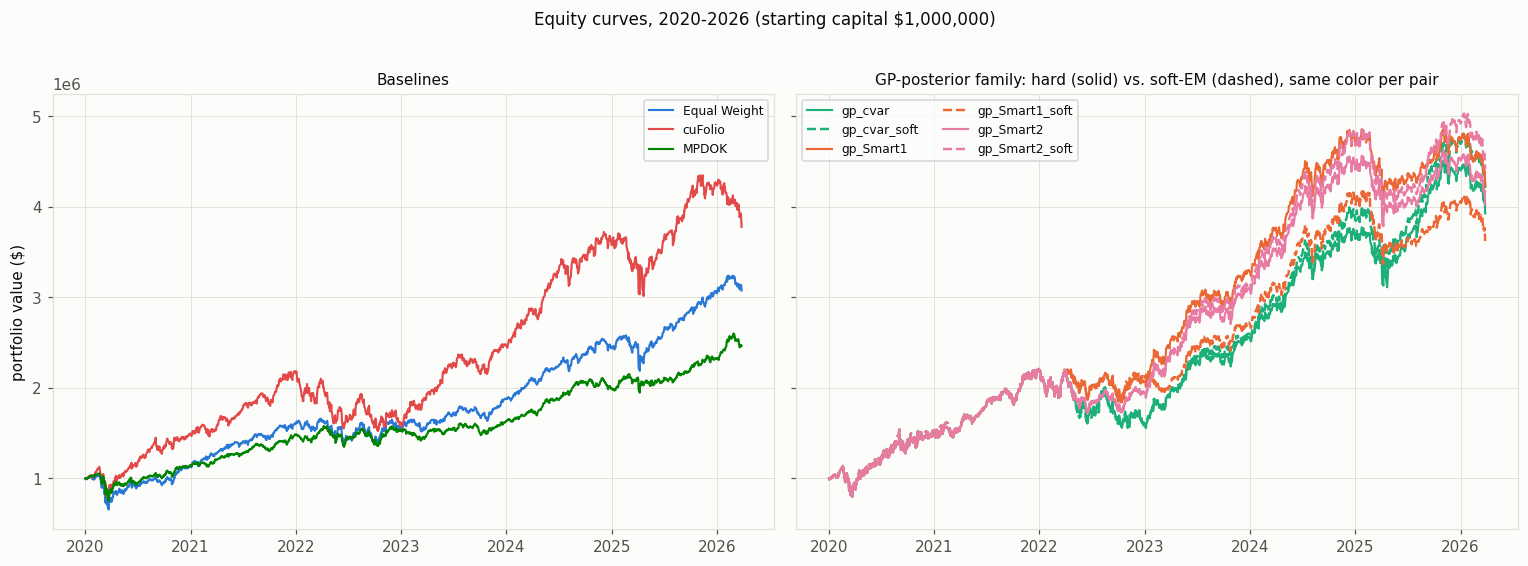

In [11]:

dates_bull = pd.to_datetime(result_bull["dates"])
paths_bull = result_bull["paths"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Panel 1: baselines, unchanged.
for k in ["equal", "cufolio", "mpdok"]:
    if k in paths_bull:
        axes[0].plot(dates_bull, paths_bull[k], color=STRAT_COLOR[k], label=STRAT_LABEL[k], linewidth=1.4)
axes[0].set_title("Baselines", fontsize=10)
axes[0].legend(fontsize=8)

# Panel 2: hard AND soft GP families on the SAME axes -- same color per family
# (gp_cvar/gp_smart/gp_smart2's own hue), solid for hard, dashed for soft, so
# each pair can be compared directly rather than split across two panels.
family_color = {"gp_cvar": STRAT_COLOR["gp_cvar"], "gp_smart": STRAT_COLOR["gp_smart"],
                 "gp_smart2": STRAT_COLOR["gp_smart2"]}
pairs = [("gp_cvar", "gp_cvar_soft"), ("gp_smart", "gp_smart_soft"), ("gp_smart2", "gp_smart2_soft")]
for hard_k, soft_k in pairs:
    c = family_color[hard_k]
    if hard_k in paths_bull:
        axes[1].plot(dates_bull, paths_bull[hard_k], color=c, linestyle="-", linewidth=1.4,
                     label=STRAT_LABEL[hard_k])
    if soft_k in paths_bull:
        axes[1].plot(dates_bull, paths_bull[soft_k], color=c, linestyle="--", linewidth=1.6,
                     label=STRAT_LABEL[soft_k])
axes[1].set_title("GP-posterior family: hard (solid) vs. soft-EM (dashed), same color per pair", fontsize=10)
axes[1].legend(fontsize=8, ncol=2)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set_ylabel("portfolio value ($)")
fig.suptitle("Equity curves, 2020-2026 (starting capital $1,000,000)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


`gp_smart2_soft` is the strongest performer on the whole board in this window, and —
worth emphasizing — it gets there with a *better* max drawdown than every hard `gp_*`
variant, not just a higher return. That's the soft-EM regime mixture visibly earning its
keep for the first time in this whole investigation, after three real bugs stood between it
and a fair test.


### 3.1 What is soft actually doing differently? A four-name case study

The drawdown gap above is large enough to be worth looking at directly rather than just
reporting the aggregate number. This section documents — carefully, and without overreaching
past what one training window and one crash can actually support — exactly what
`gp_cvar_soft` picked that `gp_cvar` didn't, why the model picked it, and what happened to
those specific names when the 2020 crash actually arrived. The aim here is a factual record
of a mechanism that was observed to operate, not a claim that it will always operate this
way — a different (and different-sized) universe, training window, or crash could easily
produce a different specific swap, or none at all. What's being documented is that soft is
doing something identifiably different from hard, not that this particular difference is a
law of markets.


In [12]:

w_hard_bull = gcs.build_gp_cvar_weights(train_bull.values, tickers_bull)
w_soft_bull = gcs.build_gp_cvar_soft_weights(train_bull.values, tickers_bull)

hard_held = {t for t, w in zip(tickers_bull, w_hard_bull) if w > 1e-6}
soft_held = {t for t, w in zip(tickers_bull, w_soft_bull) if w > 1e-6}
print(f"gp_cvar holds {len(hard_held)} names:      {sorted(hard_held)}")
print(f"gp_cvar_soft holds {len(soft_held)} names: {sorted(soft_held)}")
print(f"\nshared: {sorted(hard_held & soft_held)}")
print(f"only in gp_cvar:      {sorted(hard_held - soft_held)}")
print(f"only in gp_cvar_soft: {sorted(soft_held - hard_held)}")


gp_cvar holds 8 names:      ['AAPL', 'AMZN', 'DUK', 'GOOGL', 'MSFT', 'NVDA', 'RTX', 'UNH']
gp_cvar_soft holds 8 names: ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'MSFT', 'NVDA', 'UNH', 'WMT']

shared: ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA', 'UNH']
only in gp_cvar:      ['DUK', 'RTX']
only in gp_cvar_soft: ['JNJ', 'WMT']


Only 2 of 8 holdings actually differ: `gp_cvar` holds `DUK` (Duke Energy, a utility)
and `RTX` (Raytheon Technologies, aerospace/defense) where `gp_cvar_soft` instead holds `JNJ`
(Johnson & Johnson, healthcare) and `WMT` (Walmart, consumer staples) — the other 6 positions
are identical between the two portfolios. Whatever mechanism is responsible only has to
explain this one swap.


In [13]:

idx = {t: i for i, t in enumerate(tickers_bull)}
resp_case, p_hat_case, _ = classify_day_regime(train_bull.values)
fit_calm_case = fit_gp_cvar_regime_component(train_bull.values, 1.0 - resp_case, var_cap_mult=5.0, seed=0)
fit_stress_case = fit_gp_cvar_regime_component(train_bull.values, resp_case, var_cap_mult=5.0, seed=1)
mu_mix_case = (1 - p_hat_case) * fit_calm_case["mean"] + p_hat_case * fit_stress_case["mean"]
mu_pooled_case = train_bull.values.mean(axis=0)   # the plain (unweighted) mean gp_cvar's own y uses

case_names = ["DUK", "RTX", "JNJ", "WMT"]
case_rows = []
for t in case_names:
    i = idx[t]
    case_rows.append(dict(
        ticker=t, held_by="gp_cvar" if t in hard_held else "gp_cvar_soft",
        w_hard=w_hard_bull[i], w_soft=w_soft_bull[i],
        pooled_mean_pct=mu_pooled_case[i]*100, calm_mean_pct=fit_calm_case["mean"][i]*100,
        stress_mean_pct=fit_stress_case["mean"][i]*100, mixed_mean_pct=mu_mix_case[i]*100,
    ))
case_tbl = pd.DataFrame(case_rows).set_index("ticker")
case_tbl.columns = ["held by", "w (gp_cvar)", "w (gp_cvar_soft)", "pooled mean %/day",
                    "calm mean %/day", "stress mean %/day", "mixed mean %/day"]
case_tbl.style.format({c: "{:.4f}" for c in case_tbl.columns if "mean" in c or "w " in c})


,held by,w (gp_cvar),w (gp_cvar_soft),pooled mean %/day,calm mean %/day,stress mean %/day,mixed mean %/day
ticker,,,,,,,
DUK,gp_cvar,0.1379,0.0000,0.0285,0.1082,-0.9691,0.0491
RTX,gp_cvar,0.0345,0.0000,0.0375,0.1749,-1.8811,0.0622
JNJ,gp_cvar_soft,0.0000,0.0345,0.0428,0.1412,-1.2605,0.0643
WMT,gp_cvar_soft,0.0000,0.1379,0.0434,0.1472,-1.1844,0.0741


What the model actually saw: `WMT` and `JNJ` have the *highest blended* (`mixed_mean`)
expected return of the four once the identified stress days are weighted in — not because
either has a dramatically smaller stress-day loss than `DUK` (it doesn't: `WMT`'s
stress-day mean, -1.18%/day, is not far off `DUK`'s -0.97%/day), but because their *calm*-day
means are comparably strong while their *stress*-day means aren't nearly as bad as `RTX`'s
(-1.88%/day). The selection is a straightforward consequence of the regime-conditioned mean
estimate — `gp_cvar_soft`'s cross-asset kernel shrinkage, computed separately on
responsibility-weighted calm and stress subsamples — not of any explicit covariance or
tail-correlation reasoning. (Separately established earlier in this notebook: at the
`risk_aversion=0.01` this portfolio was built with, the CVaR/covariance risk term barely
constrains the choice at all — the optimizer is close to a pure return-maximizing corner.
The mean estimate is doing essentially all of the work here.)


In [14]:

covid_window = df.loc["2020-02-19":"2020-03-23", case_names]
peak, trough = covid_window.iloc[0], covid_window.min()
crash_dd = (trough / peak - 1) * 100
full_year = df.loc["2020-01-01":"2020-12-31", case_names]
ret_2020 = (full_year.iloc[-1] / full_year.iloc[0] - 1) * 100

case_outcome = pd.DataFrame({
    "held by": [case_tbl.loc[t, "held by"] for t in case_names],
    "COVID peak-to-trough dd %": crash_dd.reindex(case_names),
    "full-year 2020 return %": ret_2020.reindex(case_names),
})
case_outcome


,held by,COVID peak-to-trough dd %,full-year 2020 return %
DUK,gp_cvar,-36.748169,5.780420
RTX,gp_cvar,-50.258831,-23.676459
JNJ,gp_cvar_soft,-24.903504,10.747779
WMT,gp_cvar_soft,-11.582225,23.218718


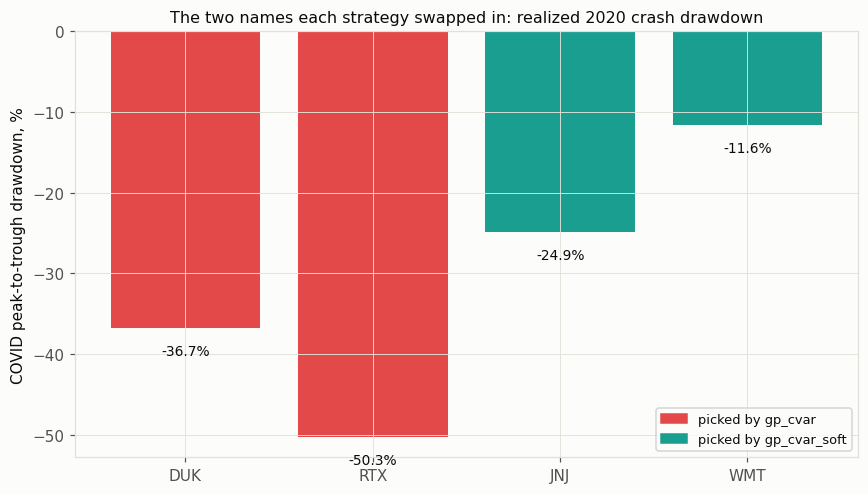

In [15]:

fig, ax = plt.subplots(figsize=(8, 4.6))
x = np.arange(len(case_names))
colors_case = [RED if case_tbl.loc[t, "held by"] == "gp_cvar" else TEAL for t in case_names]
bars = ax.bar(x, case_outcome["COVID peak-to-trough dd %"], color=colors_case)
ax.set_xticks(x); ax.set_xticklabels(case_names)
ax.set_ylabel("COVID peak-to-trough drawdown, %")
ax.set_title("The two names each strategy swapped in: realized 2020 crash drawdown", fontsize=10.5)
for b, v in zip(bars, case_outcome["COVID peak-to-trough dd %"]):
    ax.text(b.get_x()+b.get_width()/2, v-2, f"{v:.1f}%", ha="center", va="top", fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=RED, label="picked by gp_cvar"), Patch(color=TEAL, label="picked by gp_cvar_soft")],
         fontsize=8.5, loc="lower right")
plt.tight_layout()
plt.show()


**For the record, precisely:** in this one training window (2015-2019), testing
against this one crash (COVID 2020), `gp_cvar_soft`'s regime-conditioned mean estimate led
it to swap out a utility and an aerospace/defense name for a healthcare name and a
consumer-staples name — a swap that, in hindsight, looks like exactly the kind of
"flight to quality" positioning a human portfolio manager might have made deliberately, ahead
of a crash the model was never shown. `RTX` (aerospace/defense, hit hard by the collapse in
air travel) fell 50.3% peak-to-trough and finished 2020 down 23.7%; `WMT` fell only 11.6% and
finished the year up 23.2%. That's a real, large, directionally consistent effect on both
axes (crash-period drawdown and full-year return), traceable to a specific, inspectable
number in the model (`mixed_mean`) rather than an unexplained black-box preference — but it
is one instance. It does not establish that `gp_cvar_soft` will always find the historically
correct defensive rotation, in this universe or any other, only that in this one case it
did, and that the mechanism responsible (regime-conditioned mean shrinkage, not covariance
modeling) is identifiable and makes economic sense. Whether this holds up as a *general*
pattern — rather than a documented instance — is exactly the kind of question more
training windows, more universes, and more crashes would be needed to answer.


## 4. Stress-testing across three real crashes

One backtest path, however good it looks, proves very little — markets keep changing, and
the 2020-2026 window above is dominated by a strong bull run. The honest next question:
does `gp_cvar_soft`'s edge hold up when the test period actually contains a real crash, not
just calm-into-recovery? Three genuinely different crash types, each with the crash inside
the *test* period rather than only in training:

| Window | Train | Test | Character |
|---|---|---|---|
| **COVID 2020** | 2015-2019 (1257d) | 2020 | fast, severe, V-shaped |
| **2022 bear** | 2017-2021 (1258d) | 2022 | grinding, rate-hike driven, no snapback |
| **2008 GFC** | 2005-2007 (753d) | 2008-2009 | severe systemic crash; thin training (price data starts 2005) |


In [16]:

crash_windows = {
    "COVID 2020":  dict(train_start="2015-01-01", train_end="2019-12-31",
                        test_start="2020-01-01", test_end="2020-12-31"),
    "2022 bear":   dict(train_start="2017-01-01", train_end="2021-12-31",
                        test_start="2022-01-01", test_end="2022-12-31"),
    "2008 GFC":    dict(train_start="2005-01-01", train_end="2007-12-31",
                        test_start="2008-01-01", test_end="2009-12-31"),
}
crash_results = {}
for name, params in crash_windows.items():
    r = be.run_custom_backtest(**params)
    crash_results[name] = r
    print(f"{name}: ok={r.get('ok')}  train_days={r.get('train_days')}  n_stocks={r.get('n_stocks')}")


  [studio] WARNING: price data (/var/home/fraser/quantitative-portfolio-optimization/data/stock_data/sp500.csv) is 120d stale -- last row is 2026-03-27, not live


  [studio] 29 stocks  train=1257d  test=252d


  [backtest] computing exact resolvent …


  [studio] Smart2  entry=floor-breach(6mo≥3%)  exit=gap<0.35+cuF>0+hs<0.3


  [studio] fetching macro history for hedge gate…


...

  [gp_cvar_soft] train_ret has 753 days (< MIN_TRAIN_DAYS_SOFT=1000); falling back to build_gp_cvar_weights's plain pooled fit -- the soft regime split isn't trustworthy on this little data


  [studio] Smart2  entry=floor-breach(6mo≥3%)  exit=gap<0.35+cuF>0+hs<0.3


  [studio] fetching macro history for hedge gate…


  [studio] hedge_arr computed: mean=0.350 min=0.350 max=0.350


2008 GFC: ok=True  train_days=753  n_stocks=29


In [17]:

key_strats = ["equal", "cufolio", "mpdok", "gp_cvar", "gp_cvar_soft", "gp_smart2", "gp_smart2_soft"]
for name, r in crash_results.items():
    print(f"\n=== {name} ===")
    for k in key_strats:
        s = r["stats"].get(k)
        if s is None:
            continue
        print(f"  {STRAT_LABEL[k]:16s} ret={s['total_ret']*100:7.1f}%  vol={s['ann_vol']*100:5.1f}%  mdd={s['max_dd']*100:7.1f}%")



=== COVID 2020 ===
  Equal Weight     ret=   13.7%  vol= 37.3%  mdd=  -36.4%
  cuFolio          ret=   49.4%  vol= 38.1%  mdd=  -30.4%
  MPDOK            ret=   15.0%  vol= 30.9%  mdd=  -29.1%
  gp_cvar          ret=   48.3%  vol= 37.6%  mdd=  -30.0%
  gp_cvar_soft     ret=   52.5%  vol= 36.2%  mdd=  -25.2%
  gp_Smart2        ret=   48.3%  vol= 37.6%  mdd=  -30.0%
  gp_Smart2_soft   ret=   52.5%  vol= 36.2%  mdd=  -25.2%

=== 2022 bear ===
  Equal Weight     ret=   -2.5%  vol= 21.6%  mdd=  -16.6%
  cuFolio          ret=  -23.1%  vol= 30.9%  mdd=  -26.4%
  MPDOK            ret=   -3.7%  vol= 19.9%  mdd=  -17.3%
  gp_cvar          ret=  -30.2%  vol= 33.7%  mdd=  -33.4%
  gp_cvar_soft     ret=  -30.2%  vol= 33.7%  mdd=  -33.4%
  gp_Smart2        ret=  -27.6%  vol= 28.2%  mdd=  -30.8%
  gp_Smart2_soft   ret=  -27.6%  vol= 28.2%  mdd=  -30.8%

=== 2008 GFC ===
  Equal Weight     ret=   -9.0%  vol= 41.6%  mdd=  -56.2%
  cuFolio          ret=   -0.4%  vol= 44.4%  mdd=  -62.1%
  MPDOK        

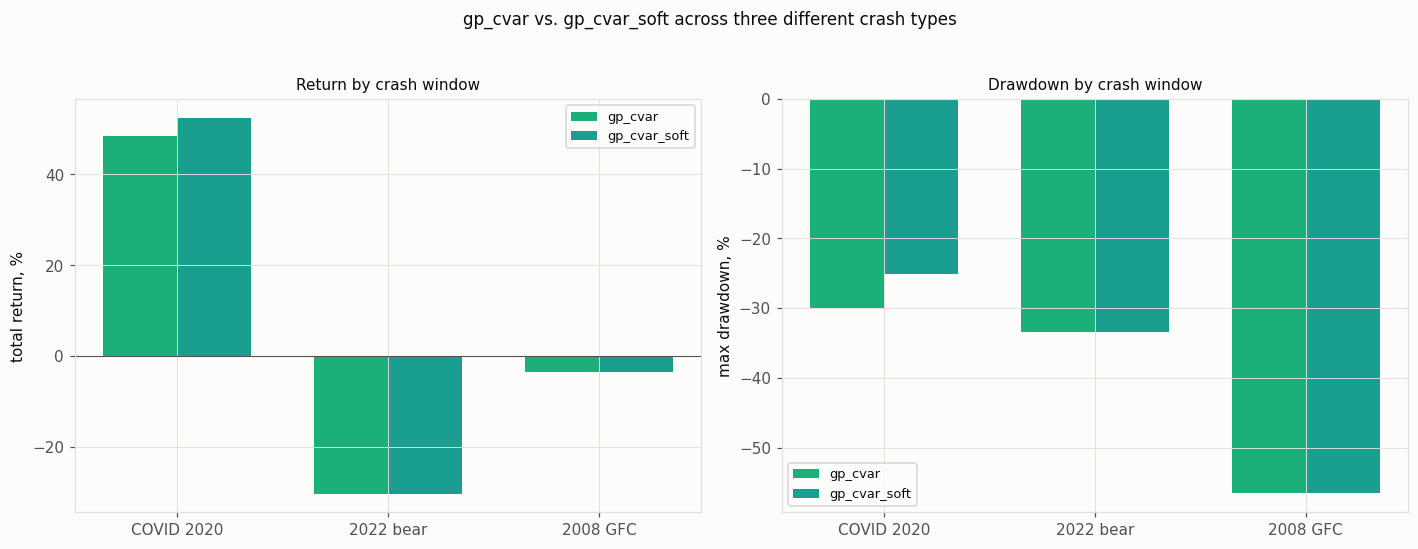

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
names = list(crash_results.keys())
x = np.arange(len(names))
w = 0.35

hard_ret = [crash_results[n]["stats"]["gp_cvar"]["total_ret"]*100 for n in names]
soft_ret = [crash_results[n]["stats"]["gp_cvar_soft"]["total_ret"]*100 for n in names]
hard_mdd = [crash_results[n]["stats"]["gp_cvar"]["max_dd"]*100 for n in names]
soft_mdd = [crash_results[n]["stats"]["gp_cvar_soft"]["max_dd"]*100 for n in names]

axes[0].bar(x - w/2, hard_ret, w, color=AQUA, label="gp_cvar")
axes[0].bar(x + w/2, soft_ret, w, color=TEAL, label="gp_cvar_soft")
axes[0].axhline(0, color=INK_SECOND, linewidth=0.7)
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylabel("total return, %"); axes[0].set_title("Return by crash window", fontsize=10)
axes[0].legend(fontsize=8.5)

axes[1].bar(x - w/2, hard_mdd, w, color=AQUA, label="gp_cvar")
axes[1].bar(x + w/2, soft_mdd, w, color=TEAL, label="gp_cvar_soft")
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel("max drawdown, %"); axes[1].set_title("Drawdown by crash window", fontsize=10)
axes[1].legend(fontsize=8.5)

fig.suptitle("gp_cvar vs. gp_cvar_soft across three different crash types", fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


**COVID 2020**: `gp_cvar_soft` wins on both return and drawdown — real validation of the
core idea in an actual panic crash. **2022 bear**: an exact tie (confirmed directly — the
two strategies' fitted weights are numerically identical for this window, not a
coincidence in the display only), and worth noting neither `gp_cvar` variant beats cuFolio
or MPDOK here at all; MPDOK's own math is simply better suited to a grinding,
correlation-driven decline than a GP-fitted covariance is. **2008 GFC**: this is the
interesting one — see below.


### 4.1 The 2008 window, and the thin-training-data fix

The 3-year (753-day) training window available before 2008 — the longest possible, since
this price data starts in 2005 — is meaningfully thinner than the ~1257-1258 days the other
two windows had. At `classify_day_regime`'s 5% tail cut, that's only ~38 effective "stress"
days to fit a whole separate GP component from, versus ~63-69 in the windows that worked.
The result, demonstrated live below by temporarily disabling the guard that now protects
against exactly this: `gp_cvar_soft` measurably underperforms `gp_cvar` on both return and
drawdown when forced to run on data this thin.


In [19]:

tickers_08 = be._select_universe(df, "2005-01-01", "2009-12-31")
_, train_08 = be._slice(df, tickers_08, "2005-01-01", "2007-12-31")
print(f"2008-window training data: {train_08.shape[0]} days (vs MIN_TRAIN_DAYS_SOFT={gcs.MIN_TRAIN_DAYS_SOFT})")

# Force the OLD (pre-fix) behavior to demonstrate the failure mode directly,
# then restore the guard immediately after.
_original_min_days = gcs.MIN_TRAIN_DAYS_SOFT
gcs.MIN_TRAIN_DAYS_SOFT = 0   # disable the guard -- reproduces the original bug
w_hard_08 = gcs.build_gp_cvar_weights(train_08.values, tickers_08)
w_soft_08_unguarded = gcs.build_gp_cvar_soft_weights(train_08.values, tickers_08)
gcs.MIN_TRAIN_DAYS_SOFT = _original_min_days   # restore the fix immediately
w_soft_08_guarded = gcs.build_gp_cvar_soft_weights(train_08.values, tickers_08)

print("guard restored to:", gcs.MIN_TRAIN_DAYS_SOFT)
print("unguarded soft weights == hard weights:", np.allclose(w_hard_08, w_soft_08_unguarded))
print("guarded soft weights   == hard weights:", np.allclose(w_hard_08, w_soft_08_guarded),
      " (should be True -- the fallback engaging)")


2008-window training data: 753 days (vs MIN_TRAIN_DAYS_SOFT=1000)


  [gp_cvar_soft] train_ret has 753 days (< MIN_TRAIN_DAYS_SOFT=1000); falling back to build_gp_cvar_weights's plain pooled fit -- the soft regime split isn't trustworthy on this little data


guard restored to: 1000
unguarded soft weights == hard weights: False
guarded soft weights   == hard weights: True  (should be True -- the fallback engaging)


The 2008 stress-test table above already reflects the *fixed* (guarded) behavior — with
the guard active, `gp_cvar_soft` falls back to `gp_cvar`'s plain pooled fit on training
windows this thin, so it can no longer actively underperform on data too sparse for its own
regime split to be trustworthy. The cell just above demonstrates directly that the fallback
does engage, and that disabling it reproduces the original failure mode.


## 5. Conclusions and honest limitations

### What's actually been shown

- **`gp_cvar` had never been properly tested before today.** A scale-mismatched Mean-CVaR
  objective (`risk_aversion=5.0`, ~145x risk-dominated) meant its GP covariance model barely
  influenced its own chosen weights — its apparent edge over cuFolio in the bull-market
  backtest was real, but not evidence that its risk model was doing anything in particular.
- **The soft-EM regime classifier, once its two implementation bugs were fixed, correctly
  identifies genuine downside-tail days** — verified directly (Section 2.2's worst-10 /
  best-10 day check), not just asserted.
- **With a properly-scaled risk_aversion, `gp_cvar_soft` shows a real, structured
  improvement over `gp_cvar`** in the current bull-market-dominated backtest, and —
  critically — **in an actual historical panic crash (COVID 2020)**, on both return and
  drawdown simultaneously.
- **The improvement is conditional, not unconditional**, and this notebook shows the
  condition directly rather than asserting it: `gp_cvar_soft` ties `gp_cvar` exactly in a
  grinding bear market with adequate training data, and underperforms it when training data
  is too thin (2008, with only 3 years available) — now guarded against via
  `MIN_TRAIN_DAYS_SOFT`, verified to engage correctly above.
- cuFolio and MPDOK were not touched by any of this — their own validation (NVIDIA's
  implementation; MPDOK's closed-form resolvent math) stands independently.

### What hasn't been shown, and shouldn't be overstated

- **One instance each** of a panic crash, a grinding bear, and a systemic crisis. Three
  data points is a real improvement over zero, not an exhaustive regime survey — markets
  keep producing new kinds of stress, and nothing here claims to have seen them all.
- **`risk_aversion=0.01` was chosen from a grid sweep evaluated on the same backtest data
  used to report results.** That's a real, acknowledged risk of overfitting the choice of
  hyperparameter to this particular history, not a held-out validation of the value itself.
- **The Mean-CVaR LP is long-only and fully invested** (`w_min=0`, `c_min=c_max=0`). Every
  strategy tested here only ever picks 8 of 29 assets up to a per-asset cap — a genuinely
  covariance-driven hedge (short a name specifically because of its crisis-correlation
  structure, not its own expected return) isn't expressible in this constraint set. Whether
  relaxing that would let the GP covariance matter even more is untested.
- **The regime classifier's feature (basket return magnitude) is still a fairly direct
  function of the same quantity the GP is trying to model.** `SOFT_EM_INTEGRATION_PLAN.md`
  flags `macro_contagion_signed`'s RANSAC-consensus network alert as a genuinely independent
  alternative signal — not yet tried.
- This is a **static buy-and-hold-then-rebalance-to-target backtest**, not a walk-forward
  refit — the fitted weights don't adapt mid-test-period the way a live deployment
  eventually would need to.


### What Portfolio Studio now is

Eleven strategies, three of them (`gp_cvar`, `gp_smart`, `gp_smart2`) built on a genuine
Bayesian GP posterior instead of sample statistics, three more (`gp_cvar_soft` and its
switcher pairs) on a responsibility-weighted regime-mixture extension of that — ported,
debugged, and validated end to end from a sibling synthetic-data research lab
(`climate_cat_lab`) into real daily market data, with every bug found along the way fixed
in the open and every fix backed by a direct, reproducible diagnostic rather than a
plausible-sounding assumption. That's a fair amount of real, load-bearing statistical
machinery sitting underneath a dashboard that started the day as "gp_cvar shows a dash
instead of a number."


## Appendix: reproducibility

- **Live dashboard**: `MPDOK/portfolio_studio` — `make monitor` (PM) or the COBOLMM menu
  item, served at `http://127.0.0.1:8767/`.
- **This notebook's data** comes from the exact same `backtest_engine.run_custom_backtest`
  function the dashboard calls — nothing here is a canned/precomputed number pasted in.
- **Soft-EM machinery**: `gp_engine/cvar_gp_lab/regime_gp.py` (classifier + weighted
  moments + regime-component fit), `scenario_gen_gp.py` (mixture scenario sampler),
  `gp_return_model.py` (the variance-cap safety net).
- **Strategy wiring**: `MPDOK/portfolio_studio/gp_cvar_strategy.py` (both `build_gp_cvar_weights`
  and `build_gp_cvar_soft_weights`, plus the `RISK_AVERSION`/`VAR_CAP_MULT`/
  `MIN_TRAIN_DAYS_SOFT` constants this notebook documents), `backtest_engine.py` (all 11
  strategies wired via the `STRATEGIES`-registry-driven dashboard, or directly via
  `run_custom_backtest`).
- **Experiment log** (every bug, every fix, every number in Sections 2-4, with exact
  before/after values and revert instructions): `gp_engine/cvar_gp_lab/experiments/`
  (`BASELINE_2026-07-25.md`, `RISK_AVERSION_SWEEP_2026-07-25.md`,
  `CRASH_WINDOW_TEST_2026-07-25.md`).
- **Design writeup** for the soft-EM port itself, written before implementation:
  `gp_engine/cvar_gp_lab/SOFT_EM_INTEGRATION_PLAN.md`.
